In [ ]:
pip install -r requirements.txt

## Comparing Issue Similarity

In [27]:
import pandas as pd

# Load the data reports, top_issues folder

#Input path for the data
input_path = "../data/reports/top_issues"

wave_issues = {}
for wave in range(4, 8):
    file_path = f"{input_path}/k5_wave{wave}_top_issues_labeled.csv"
    wave_issues[wave] = pd.read_csv(file_path)

In [28]:
from sklearn.metrics import jaccard_score
from itertools import product
import numpy as np

def jaccard_similarity(set1, set2):
    return len(set(set1) & set(set2)) / len(set(set1) | set(set2))

# Create coherence matrices between every pair of waves
similarity_matrices = {}

for wave1 in range(4, 8):
    for wave2 in range(wave1 + 1, 8):
        topics1 = wave_issues[wave1]
        topics2 = wave_issues[wave2]

        sim_matrix = np.zeros((topics1.shape[1], topics2.shape[1]))

        for i, j in product(range(topics1.shape[1]), range(topics2.shape[1])):
            sim_matrix[i, j] = jaccard_similarity(topics1.iloc[:, i], topics2.iloc[:, j])

        similarity_matrices[(wave1, wave2)] = pd.DataFrame(
            sim_matrix,
            index=[f"W{wave1}_Ideology_{i+1}" for i in range(topics1.shape[1])],
            columns=[f"W{wave2}_Ideology_{j+1}" for j in range(topics2.shape[1])]
        )


In [29]:
import os

# Define the output path
output_path = os.path.join("../data/reports/ideology_coherence")

# Ensure the output directory exists
os.makedirs(output_path, exist_ok=True)

for pair, matrix in similarity_matrices.items():
    print(f"\n🧠 Ideological Coherence Between Wave {pair[0]} and Wave {pair[1]}")
    print(matrix.round(2))

    # Save the matrix to the specified folder
    matrix_filename = f"coherence_wave{pair[0]}_wave{pair[1]}.csv"
    matrix_path = os.path.join(output_path, matrix_filename)
    
    # Save the file, overwriting if it already exists
    matrix.to_csv(matrix_path, index=False)
    print(f"Saved matrix to: {matrix_path}")


🧠 Ideological Coherence Between Wave 4 and Wave 5
               W5_Ideology_1  W5_Ideology_2  W5_Ideology_3  W5_Ideology_4  \
W4_Ideology_1           0.11           0.25           0.33           0.25   
W4_Ideology_2           0.11           0.33           0.54           0.05   
W4_Ideology_3           0.05           0.11           0.54           0.05   
W4_Ideology_4           0.05           0.00           0.00           0.82   
W4_Ideology_5           0.00           0.11           0.18           0.25   

               W5_Ideology_5  
W4_Ideology_1           0.18  
W4_Ideology_2           0.11  
W4_Ideology_3           0.11  
W4_Ideology_4           0.18  
W4_Ideology_5           0.82  
Saved matrix to: ../data/reports/ideology_coherence/coherence_wave4_wave5.csv

🧠 Ideological Coherence Between Wave 4 and Wave 6
               W6_Ideology_1  W6_Ideology_2  W6_Ideology_3  W6_Ideology_4  \
W4_Ideology_1           0.05           0.25           0.18           0.25   
W4_Ideology_2    

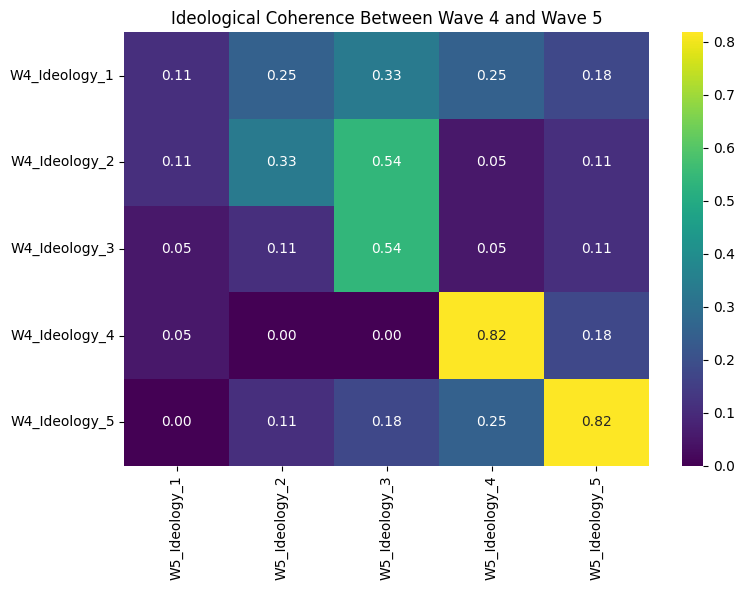

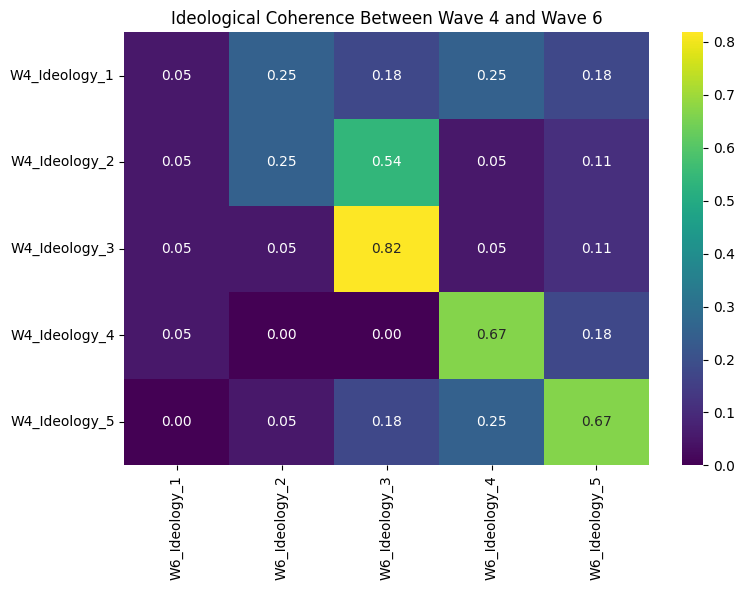

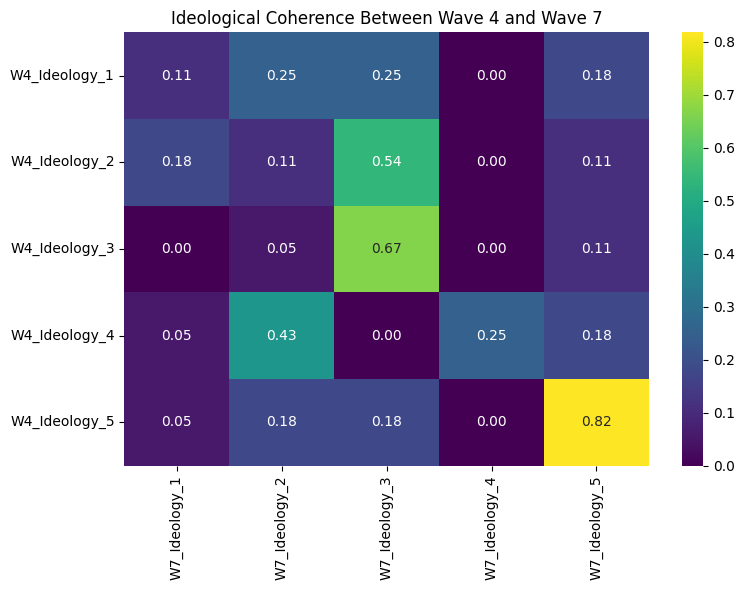

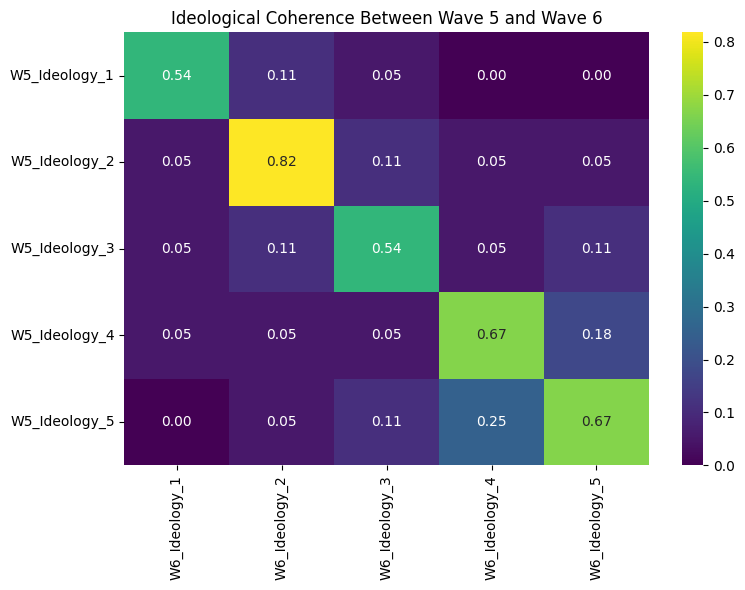

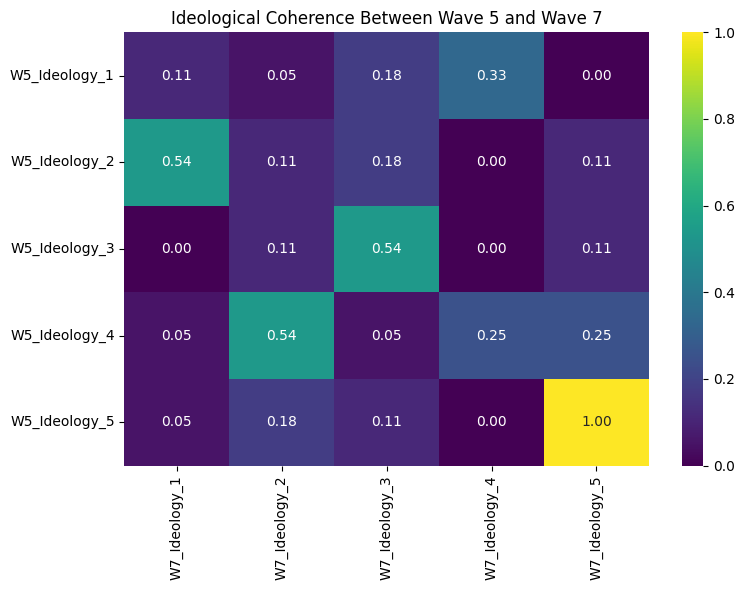

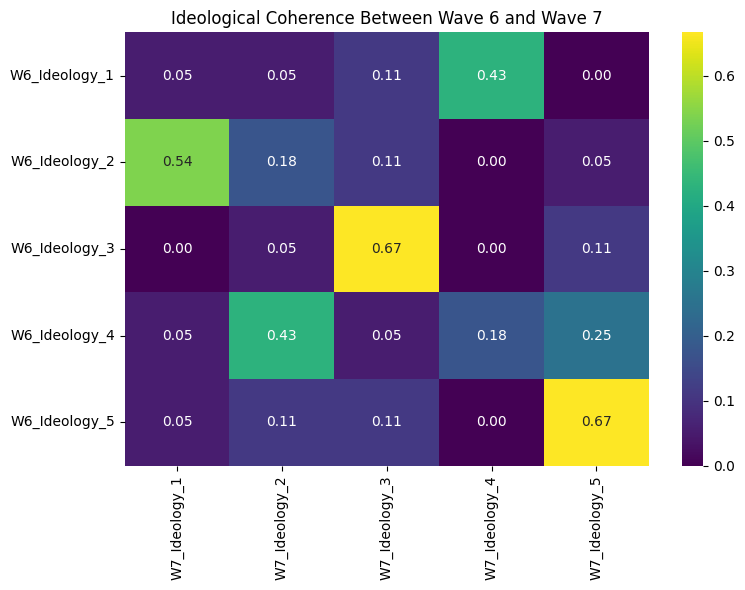

In [30]:
import seaborn as sns
import matplotlib.pyplot as plt

for pair, matrix in similarity_matrices.items():
    plt.figure(figsize=(8, 6))
    sns.heatmap(matrix, annot=True, fmt=".2f", cmap="viridis")
    plt.title(f"Ideological Coherence Between Wave {pair[0]} and Wave {pair[1]}")
    plt.tight_layout()
    plt.show()